## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input

In [4]:
print("Working!")

Working!


## 2. Load Dataset

In [7]:
BASE_DIR = 'archive (2)/UTKFace'

In [8]:
image_paths   = []
age_labels    = []
gender_labels = []

In [9]:
for filename in tqdm(os.listdir(BASE_DIR)):
    
    if not filename.endswith(('.jpg', '.jpeg', '.png')):
        continue
    
    image_path = os.path.join(BASE_DIR, filename)
    temp = filename.split('_')
    
    if len(temp) < 2:
        continue
    
    try:
        age = int(temp[0])
        gender = int(temp[1])
    except ValueError:
        continue
    
    image_paths.append(image_path)
    age_labels.append(age)
    gender_labels.append(gender)

  0%|          | 0/23709 [00:00<?, ?it/s]

In [10]:
df = pd.DataFrame()
df['image'], df['age'], df['gender'] = image_paths, age_labels, gender_labels
df.head()

,image,age,gender
0,archive (2)/UTKFace\100_0_0_20170112213500903....,100,0
1,archive (2)/UTKFace\100_0_0_20170112215240346....,100,0
2,archive (2)/UTKFace\100_1_0_20170110183726390....,100,1
3,archive (2)/UTKFace\100_1_0_20170112213001988....,100,1
4,archive (2)/UTKFace\100_1_0_20170112213303693....,100,1


In [11]:
gender_dict = {0:'Male', 1:'Female'}

In [12]:
print(df.head())
print(f"Total valid images loaded: {len(df)}")

                                               image  age  gender
0  archive (2)/UTKFace\100_0_0_20170112213500903....  100       0
1  archive (2)/UTKFace\100_0_0_20170112215240346....  100       0
2  archive (2)/UTKFace\100_1_0_20170110183726390....  100       1
3  archive (2)/UTKFace\100_1_0_20170112213001988....  100       1
4  archive (2)/UTKFace\100_1_0_20170112213303693....  100       1
Total valid images loaded: 23708


## 3. Sample Images

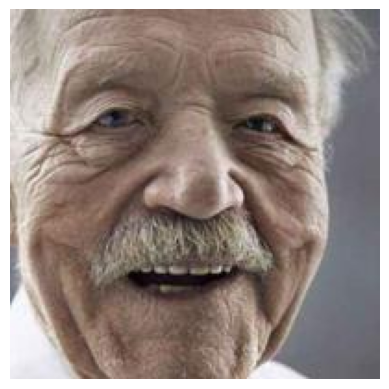

In [13]:
from PIL import Image
img = Image.open(df['image'][0])
plt.axis('off')
plt.imshow(img);

<Axes: xlabel='age', ylabel='Density'>

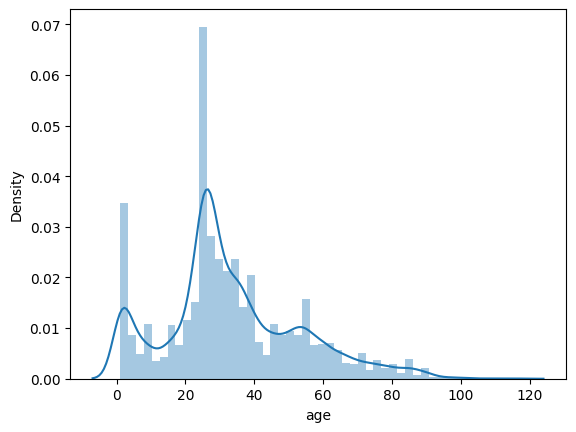

In [14]:
sns.distplot(df['age'])

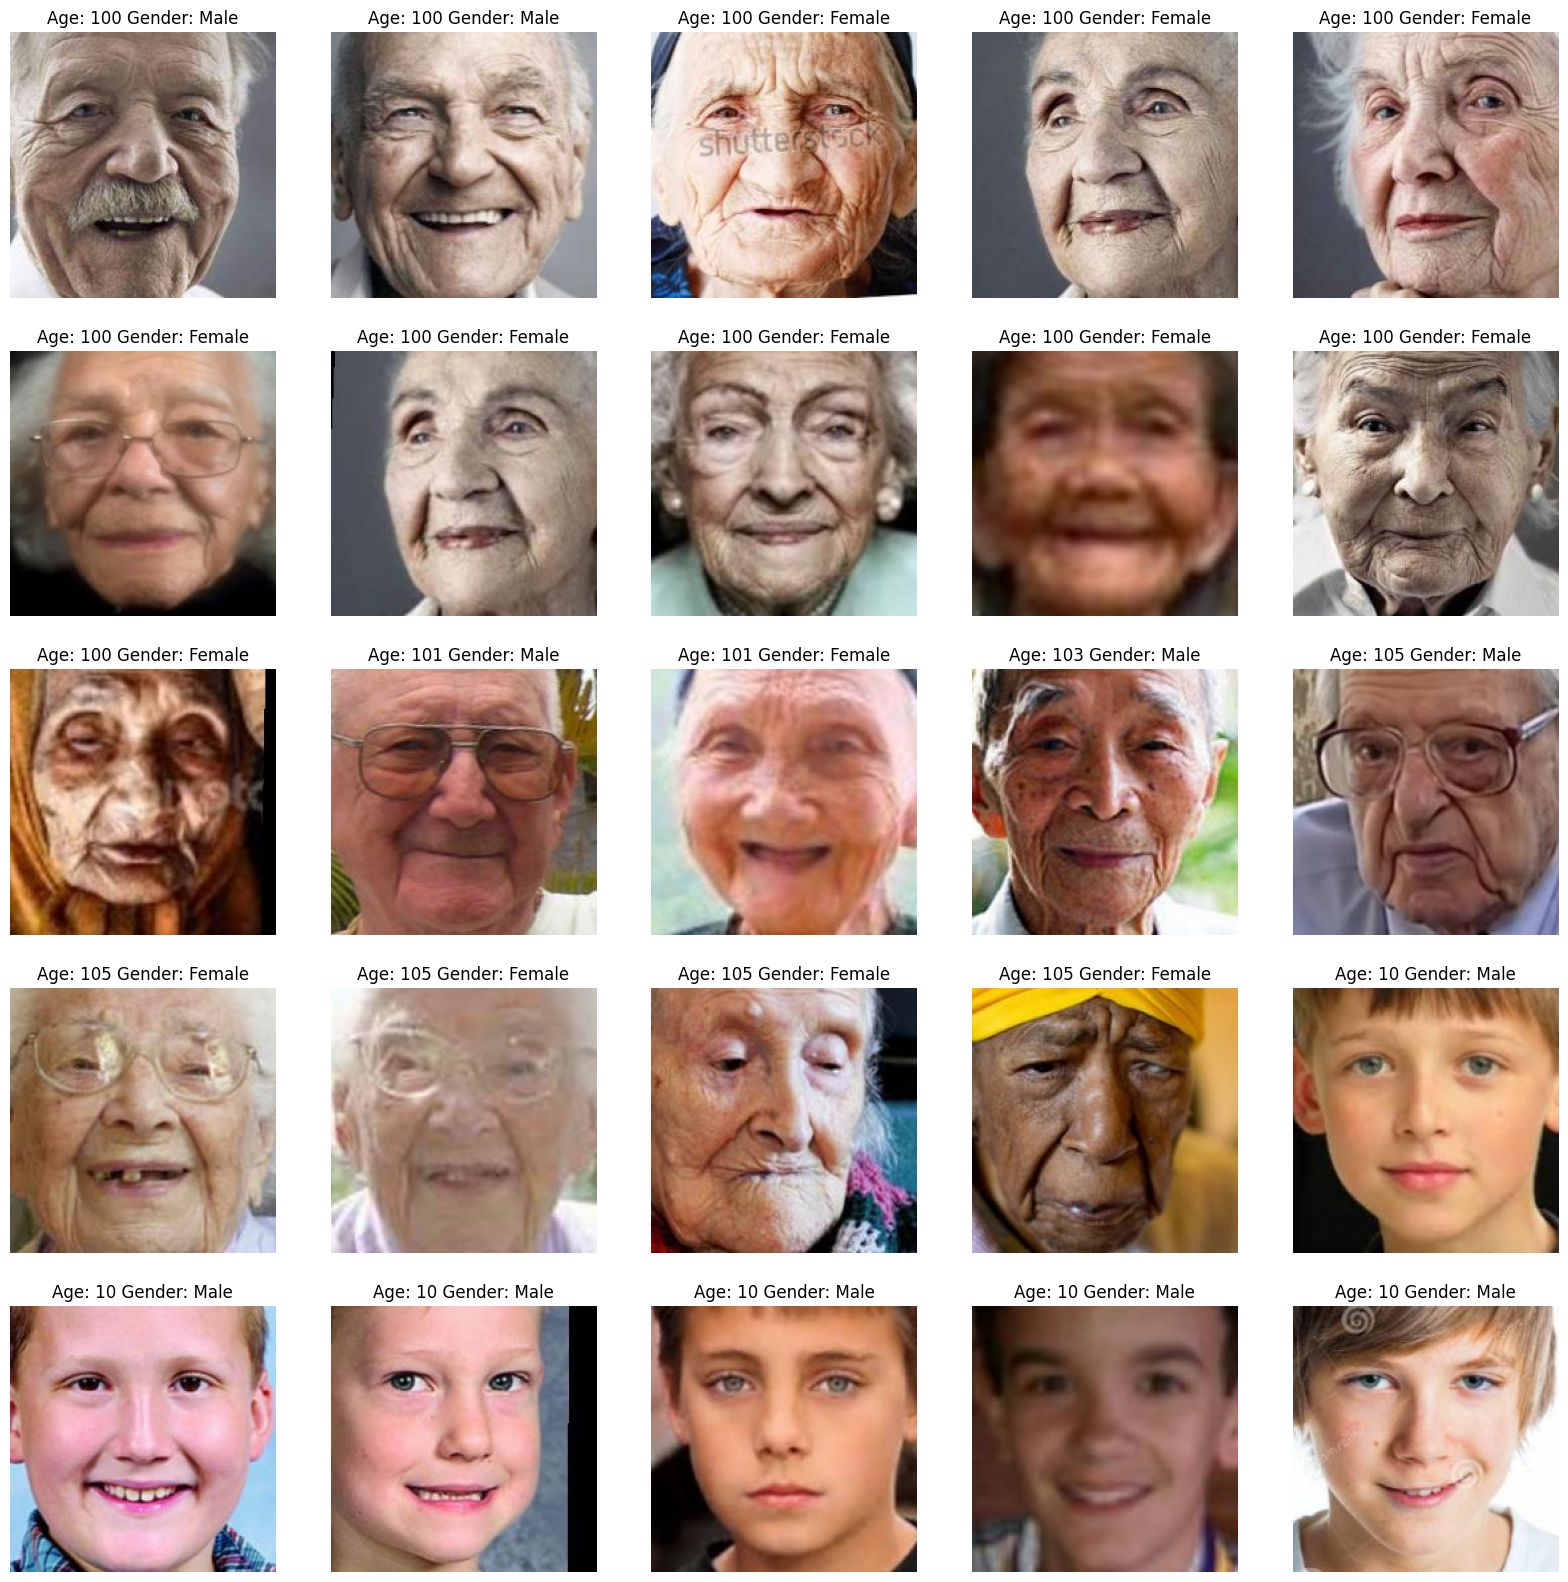

In [15]:
plt.figure(figsize=(20, 20))
files = df.iloc[0:25]

for index, file, age, gender in files.itertuples():
    plt.subplot(5, 5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title(f"Age: {age} Gender: {gender_dict[gender]}")
    plt.axis('off')


## 4. Feature Extraction

In [16]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode='grayscale')
        img = img.resize((128, 128), Image.LANCZOS)
        img = np.array(img)
        features.append(img)
        
    features = np.array(features)
    features = features.reshape(len(features), 128, 128, 1)
    return features

In [17]:
X = extract_features(df['image'])
X.shape

  0%|          | 0/23708 [00:00<?, ?it/s]

(23708, 128, 128, 1)

In [18]:
# Normalise pixel values to [0, 1]
X = X / 255.0

In [19]:
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])

In [20]:
input_shape = (128, 128, 1)

## 5. Build the CNN

In [21]:
inputs = Input((input_shape))

In [22]:
# convolutional layers
conv_1 = Conv2D(32, kernel_size=(3, 3), activation='relu') (inputs)
maxp_1 = MaxPooling2D(pool_size=(2, 2)) (conv_1)
conv_2 = Conv2D(64, kernel_size=(3, 3), activation='relu') (maxp_1)
maxp_2 = MaxPooling2D(pool_size=(2, 2)) (conv_2)
conv_3 = Conv2D(128, kernel_size=(3, 3), activation='relu') (maxp_2)
maxp_3 = MaxPooling2D(pool_size=(2, 2)) (conv_3)
conv_4 = Conv2D(256, kernel_size=(3, 3), activation='relu') (maxp_3)
maxp_4 = MaxPooling2D(pool_size=(2, 2)) (conv_4)

flatten = Flatten() (maxp_4)

In [23]:
# fully connected layers
dense_1 = Dense(256, activation='relu') (flatten)
dense_2 = Dense(256, activation='relu') (flatten)

dropout_1 = Dropout(0.3) (dense_1)
dropout_2 = Dropout(0.3) (dense_2)

output_1 = Dense(1, activation='sigmoid', name='gender_out') (dropout_1)
output_2 = Dense(1, activation='relu', name='age_out') (dropout_2)

model = Model(inputs=[inputs], outputs=[output_1, output_2])

model.compile(loss=['binary_crossentropy', 'mae'], optimizer='adam', metrics=['accuracy', 'mae'])

In [24]:
pip install pydot graphviz

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pydot in c:\python311\lib\site-packages (4.0.1)




[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


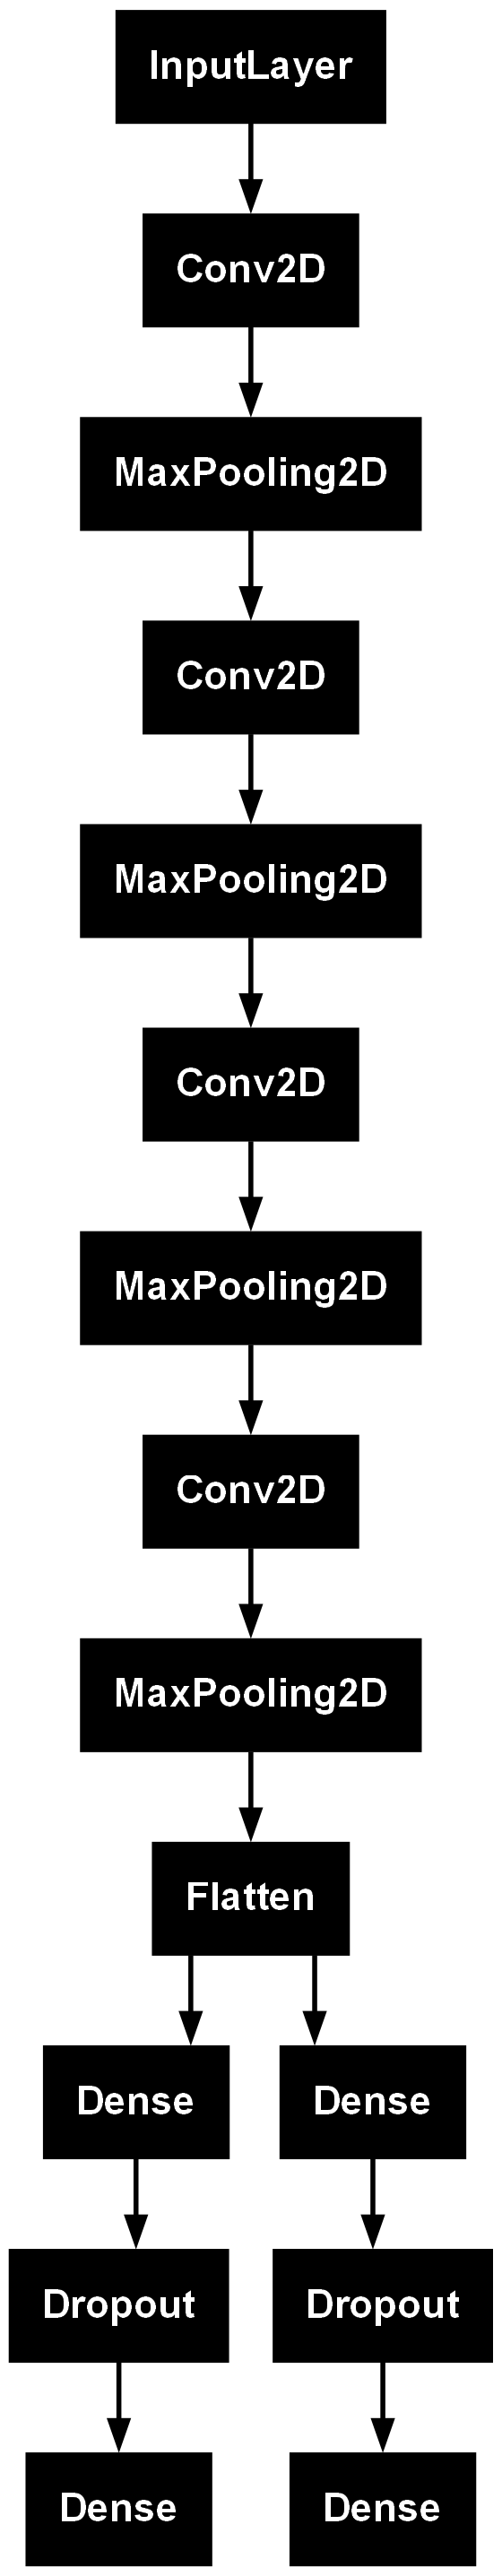

In [25]:
# plot the model
from tensorflow.keras.utils import plot_model
plot_model(model)

## 6. Train the CNN

In [27]:
history = model.fit(
    x                = X,
    y                = [y_gender, y_age],
    batch_size       = 32,
    epochs           = 25,
    validation_split = 0.2
)

Epoch 1/25
593/593 ━━━━━━━━━━━━━━━━━━━━ 149s 240ms/step - age_out_loss: 12.0330 - age_out_mae: 12.0330 - gender_out_accuracy: 0.5117 - gender_out_loss: 0.7240 - loss: 12.7571 - val_age_out_loss: 29.2575 - val_age_out_mae: 29.3791 - val_gender_out_accuracy: 0.6917 - val_gender_out_loss: 0.5913 - val_loss: 29.9722
Epoch 2/25
593/593 ━━━━━━━━━━━━━━━━━━━━ 147s 247ms/step - age_out_loss: 7.7349 - age_out_mae: 7.7349 - gender_out_accuracy: 0.7582 - gender_out_loss: 0.4989 - loss: 8.2337 - val_age_out_loss: 28.7282 - val_age_out_mae: 28.8541 - val_gender_out_accuracy: 0.7625 - val_gender_out_loss: 0.5084 - val_loss: 29.3632
Epoch 3/25
593/593 ━━━━━━━━━━━━━━━━━━━━ 144s 242ms/step - age_out_loss: 7.0054 - age_out_mae: 7.0054 - gender_out_accuracy: 0.8269 - gender_out_loss: 0.3752 - loss: 7.3806 - val_age_out_loss: 28.4046 - val_age_out_mae: 28.5378 - val_gender_out_accuracy: 0.7739 - val_gender_out_loss: 0.4636 - val_loss: 29.0023
Epoch 4/25
593/593 ━━━━━━━━━━━━━━━━━━━━ 128s 216ms/step - age_ou

## 7. Plot the Results

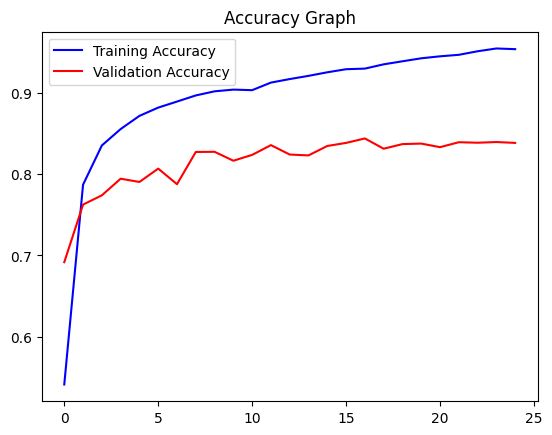

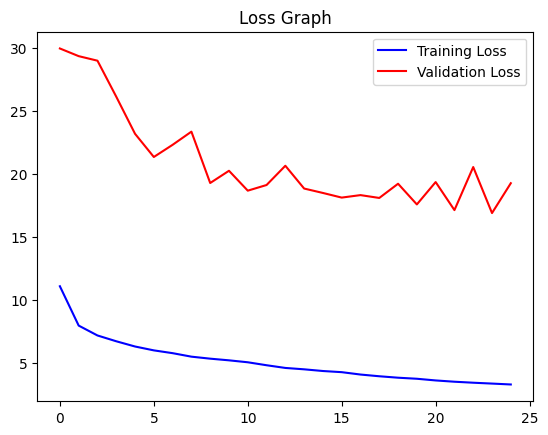

In [ ]:
# plot results for gender
acc = history.history['gender_out_accuracy']
val_acc = history.history['val_gender_out_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

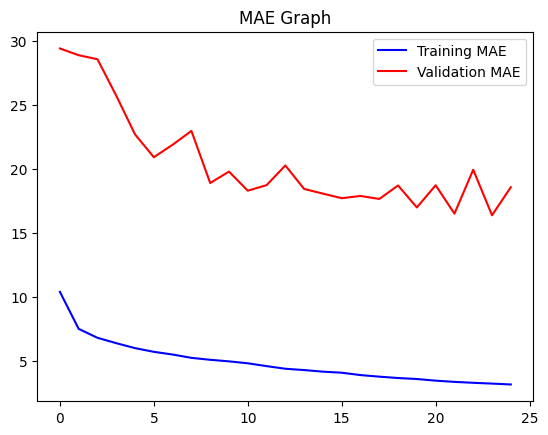

In [ ]:
# plot results for age
loss = history.history['age_out_mae']
val_loss = history.history['val_age_out_mae']
epochs = range(len(loss))

plt.plot(epochs, loss, 'b', label='Training MAE')
plt.plot(epochs, val_loss, 'r', label='Validation MAE')
plt.title('MAE Graph')
plt.legend()
plt.show()

## 8. Prediction Function

Original Gender: Female Original Age: 29
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step
Predicted Gender: Female Predicted Age: 28


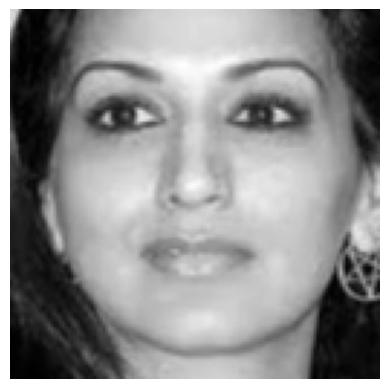

In [ ]:
image_index = 10000
print("Original Gender:", gender_dict[y_gender[image_index]], "Original Age:", y_age[image_index])
# predict from model
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))
pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])
print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128),  cmap='gray');

Original Gender: Male Original Age: 21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Predicted Gender: Male Predicted Age: 20


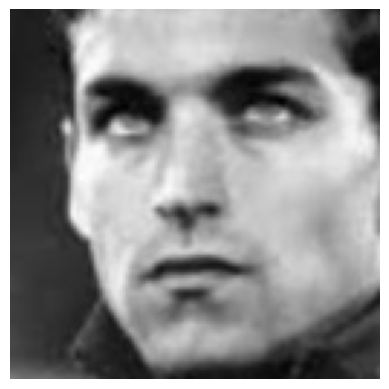

In [ ]:
image_index = 3000
print("Original Gender:", gender_dict[y_gender[image_index]], "Original Age:", y_age[image_index])
# predict from model
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))
pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])
print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray');

Original Gender: Female Original Age: 22
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted Gender: Female Predicted Age: 20


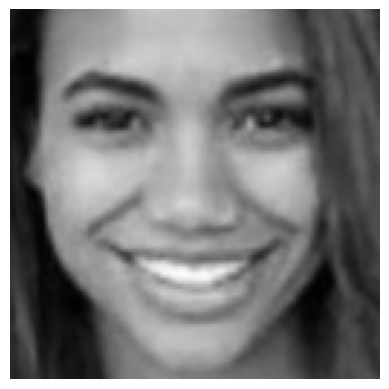

In [ ]:
image_index = 3499
print("Original Gender:", gender_dict[y_gender[image_index]], "Original Age:", y_age[image_index])
# predict from model
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))
pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])
print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray');

In [35]:
model.save("age_gender_model.keras")